In [2]:
import pandas as pd

comodity_prices = pd.read_csv("../raw data/brent_price_weekly.csv")
main_data_cleaned = pd.read_csv("../main dataset/main_data_cleaned.csv")

In [3]:
comodity_prices.head()

,Year_Week,Brent_Price_USD,Start_Date,End_Date,trading_days_count
0,2000-W01,23.914,1/7/2000,1/13/2000,5
1,2000-W02,26.046,1/14/2000,1/20/2000,5
2,2000-W03,27.106,1/21/2000,1/27/2000,5
3,2000-W04,27.154,1/28/2000,2/3/2000,5
4,2000-W05,27.558,2/4/2000,2/10/2000,5


In [4]:
main_data_cleaned.head()

,Year_Week,year,location,code,vegetable_type,price,no_of_holidays,vegetable_zone,seasonality,lanka_auto_diesel_price,mean_apparent_temperature,rain_sum,usd_exchange_rate,week_num
0,2013-W01,2013,Thambuththegama,323,PUMPKIN,37.0,NaN,NaN,NaN,115.0,NaN,NaN,127.0721,1
1,2013-W01,2013,Kandy,323,PUMPKIN,42.0,NaN,NaN,NaN,115.0,NaN,NaN,127.0721,1
2,2013-W01,2013,Dambulla,323,PUMPKIN,48.0,NaN,NaN,NaN,115.0,NaN,NaN,127.0721,1
3,2013-W01,2013,Puttalam,323,PUMPKIN,52.0,NaN,NaN,NaN,115.0,NaN,NaN,127.0721,1
4,2013-W01,2013,Nuwaraeliya,323,PUMPKIN,54.0,NaN,NaN,NaN,115.0,NaN,NaN,127.0721,1


In [5]:
usd_exchange_rates = main_data_cleaned[['Year_Week', 'usd_exchange_rate']].drop_duplicates(subset=['Year_Week']).reset_index(drop=True)

In [6]:
comodity_prices_trimmed = comodity_prices[
    (comodity_prices['Year_Week'] >= '2013-W01') & (comodity_prices['Year_Week'] <= '2019-W52')
].reset_index(drop=True)

In [7]:
comodity_prices_trimmed.head()

,Year_Week,Brent_Price_USD,Start_Date,End_Date,trading_days_count
0,2013-W01,112.828,1/4/2013,1/10/2013,5
1,2013-W02,111.064,1/11/2013,1/17/2013,5
2,2013-W03,113.175,1/18/2013,1/24/2013,4
3,2013-W04,114.798,1/25/2013,1/31/2013,5
4,2013-W05,116.484,2/1/2013,2/7/2013,5


In [8]:
new_df = comodity_prices_trimmed[['Year_Week', 'Brent_Price_USD']].merge(
    usd_exchange_rates[['Year_Week', 'usd_exchange_rate']],
    on='Year_Week',
    how='left'
)

new_df.head()

,Year_Week,Brent_Price_USD,usd_exchange_rate
0,2013-W01,112.828,127.0721
1,2013-W02,111.064,126.3521
2,2013-W03,113.175,126.7411
3,2013-W04,114.798,126.8829
4,2013-W05,116.484,126.3089


In [9]:
new_df['Brent_Price_LKR'] = new_df['Brent_Price_USD'] * new_df['usd_exchange_rate']
new_df.head()

,Year_Week,Brent_Price_USD,usd_exchange_rate,Brent_Price_LKR
0,2013-W01,112.828,127.0721,14337.290899
1,2013-W02,111.064,126.3521,14033.169634
2,2013-W03,113.175,126.7411,14343.923993
3,2013-W04,114.798,126.8829,14565.903154
4,2013-W05,116.484,126.3089,14712.965908


In [10]:
diesel_prices = main_data_cleaned[['Year_Week', 'lanka_auto_diesel_price']].drop_duplicates(subset=['Year_Week'])

new_df = new_df.merge(
    diesel_prices,
    on='Year_Week',
    how='left')

In [11]:
new_df.head()

,Year_Week,Brent_Price_USD,usd_exchange_rate,Brent_Price_LKR,lanka_auto_diesel_price
0,2013-W01,112.828,127.0721,14337.290899,115.0
1,2013-W02,111.064,126.3521,14033.169634,115.0
2,2013-W03,113.175,126.7411,14343.923993,115.0
3,2013-W04,114.798,126.8829,14565.903154,115.0
4,2013-W05,116.484,126.3089,14712.965908,115.0


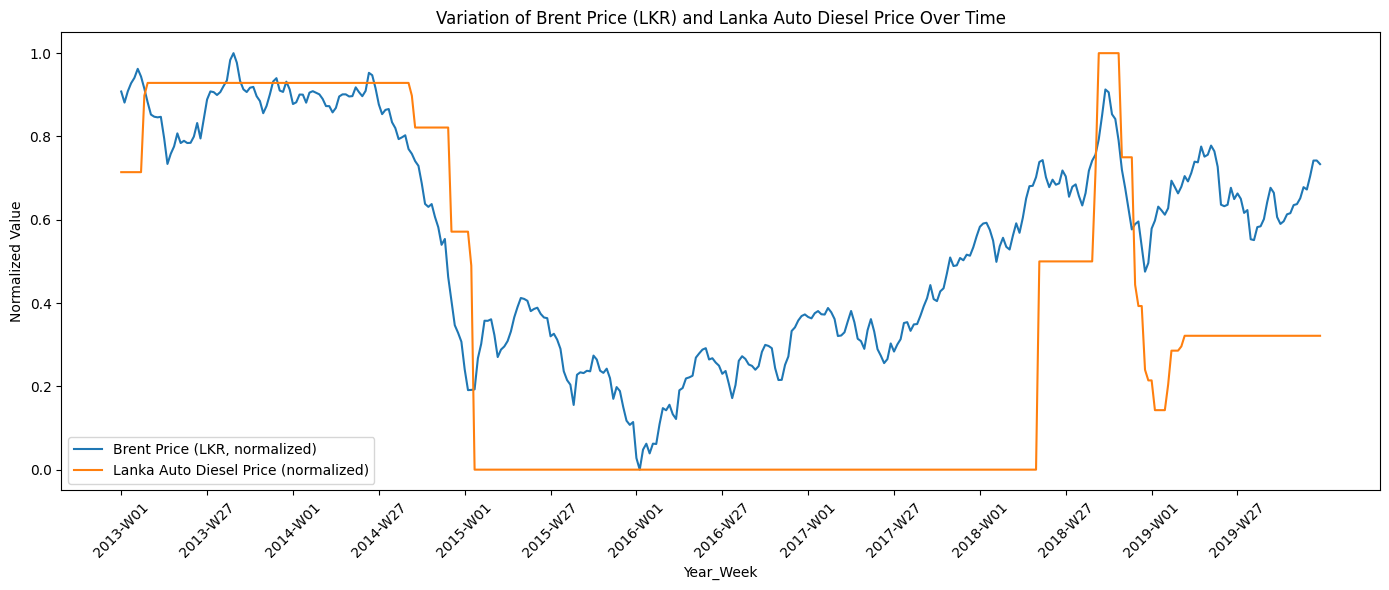

In [12]:
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

# Normalize the columns
scaler = MinMaxScaler()
normalized = scaler.fit_transform(new_df[['Brent_Price_LKR', 'lanka_auto_diesel_price']])
new_df['Brent_Price_LKR_norm'] = normalized[:, 0]
new_df['lanka_auto_diesel_price_norm'] = normalized[:, 1]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(new_df['Year_Week'], new_df['Brent_Price_LKR_norm'], label='Brent Price (LKR, normalized)')
plt.plot(new_df['Year_Week'], new_df['lanka_auto_diesel_price_norm'], label='Lanka Auto Diesel Price (normalized)')
plt.xlabel('Year_Week')
plt.ylabel('Normalized Value')
plt.title('Variation of Brent Price (LKR) and Lanka Auto Diesel Price Over Time')
plt.legend()
plt.xticks(ticks=range(0, len(new_df), 26), labels=new_df['Year_Week'][::26], rotation=45)
plt.tight_layout()
plt.show()

In [13]:
new_df.head()

,Year_Week,Brent_Price_USD,usd_exchange_rate,Brent_Price_LKR,lanka_auto_diesel_price,Brent_Price_LKR_norm,lanka_auto_diesel_price_norm
0,2013-W01,112.828,127.0721,14337.290899,115.0,0.907931,0.714286
1,2013-W02,111.064,126.3521,14033.169634,115.0,0.881357,0.714286
2,2013-W03,113.175,126.7411,14343.923993,115.0,0.908511,0.714286
3,2013-W04,114.798,126.8829,14565.903154,115.0,0.927908,0.714286
4,2013-W05,116.484,126.3089,14712.965908,115.0,0.940758,0.714286


In [14]:
new_df.to_csv('../cleaned data/brent_weekly_prices.csv')